In [580]:
import numpy as np
import torch.nn as nn
from tqdm import tqdm
from torch.distributions.multivariate_normal import MultivariateNormal
from scipy.optimize import linear_sum_assignment
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

/home/id94ebid/projects/continuous_GMM


In [581]:
# B = 16 # Batch size
T = 20 # Number of timesteps
F = 2 # Numbers of features
K = 4 # Number of mixture components
# r = 128 # Estimate the covariance matrix
R = 64 # Number of eigenvalues
r = 4 # Number of eigenvalues in the mean approximation
n = 100 # Number of samples
c = 4 # Number of clusters
dt = 1/(T-1)
ts = torch.linspace(0, 1, T)
#X = torch.randn((B, T)) #torch.randn((B, T, F))

lr = 0.1
lambd_reg = 1e-3

sigma = 5 # Functional RBF
alpha=-1/(2*sigma**2)

sigmas = np.array([1, 1, 1, 1]) # Mixture model data
assert len(sigmas)==K

In [582]:
def rbf_fkernel(x1, x2, dt, alpha=-1.0): # (B, T, F) or (B, T)
    y = dt*torch.square(x1-x2).sum(-1) # (B, B, T)
    norm = (y[..., 0] / 2 + y[..., 1:-1].sum(dim=-1) + y[..., -1] / 2) # (B, B)
    return torch.exp(alpha*norm)

def rbf_kernel(x1, x2, sigma): # (B, F) or (B)
    norm = torch.square(x1-x2)#.sum(-1) # (B, B)
    return torch.exp(-1/(2*sigma**2)*norm)

In [583]:
time_range = (0.0, 1.0)
ts = torch.linspace(time_range[0], time_range[1], T)
t1, t2 = ts[:, None], ts[None, :]

In [584]:
def generate_stochastic_processes(n_samples, n_features, n_clusters, n_timesteps):
    # 1. Setup Time
    # Reshape for kernel computations: (T, 1)
    ts_col = ts[:, None] 
    
    # 2. Distribute samples among clusters
    # Splits n_samples as evenly as possible among m clusters
    base_count = n_samples // n_clusters
    remainder = n_samples % n_clusters
    samples_per_cluster = [base_count + 1 if i < remainder else base_count for i in range(n_clusters)]
    print(f"Samples per cluster: {samples_per_cluster}")
    
    all_cluster_data = []
    all_means_data = []
    all_labels = []

    print(f"Generating {n_samples} samples across {n_clusters} clusters with {n_features} features...")

    # 3. Generate Data per Cluster
    for cluster_idx in range(n_clusters):
        n_c = samples_per_cluster[cluster_idx]
        
        # If a cluster has 0 samples allocated, skip
        if n_c == 0: continue

        # We collect features for this specific cluster here
        cluster_features = []
        cluster_means = []
        
        # To ensure this cluster looks different from others, we randomize the 
        # mean function parameters and kernel parameters for this cluster.
        
        for feature_idx in range(n_features):
            # --- A. Define Mean Function parameters for this cluster/feature ---
            # Mean = A * cos(freq * t + phase) + bias
            amp = torch.rand(1) * 10 + 2       # Random amplitude between 2 and 12
            freq = torch.rand(1) * 3 + 0.5     # Random freq between 0.5 and 3.5
            phase = torch.rand(1) * 2 * np.pi  # Random phase
            bias = torch.randn(1) * 5          # Random vertical shift
            
            mean_vec = amp * torch.cos(freq * ts + phase) + bias
            
            # --- B. Define Covariance (Kernel) ---
            # Randomize length_scale slightly per cluster to vary smoothness
            ls = 2#0.5 + torch.rand(1) * 1.5     # Length scale between 0.5 and 2.0
            
            # Calculate Kernel K
            K = rbf_kernel(ts_col, ts_col, sigma=ls)
            
            # Add jitter for numerical stability (Cholesky decomposition)
            K = K + 1e-5 * torch.eye(n_timesteps)
            
            # --- C. Sample from Multivariate Normal ---
            # We sample n_c times for this specific feature
            dist = MultivariateNormal(mean_vec, K)
            # shape: (n_c, T)
            feature_samples = dist.sample((n_c,))
            
            cluster_features.append(feature_samples)
            cluster_means.append(mean_vec)
        
        # Stack features along the last dimension
        # From list of (n_c, T) -> (n_c, T, F)
        X_cluster = torch.stack(cluster_features, dim=-1)
        all_cluster_data.append(X_cluster)
        all_means = torch.stack(cluster_means, dim=-1)
        all_means_data.append(all_means)
        
        # Create labels
        all_labels.append(torch.full((n_c,), cluster_idx, dtype=torch.long))

    # 4. Concatenate all clusters
    X = torch.cat(all_cluster_data, dim=0)  # Shape: (N, T, F)
    real_means = torch.stack(all_means_data)  # Shape: (K, T, F)
    labels = torch.cat(all_labels, dim=0)   # Shape: (N,)

    # Optional: Shuffle the dataset so clusters aren't contiguous
    perm = torch.randperm(n_samples)
    X = X[perm]
    labels = labels[perm]

    return X, labels, real_means, samples_per_cluster

In [585]:
Xs, targets, real_means, samples_per_cluster = generate_stochastic_processes(n, F, c, T)

Samples per cluster: [25, 25, 25, 25]
Generating 100 samples across 4 clusters with 2 features...


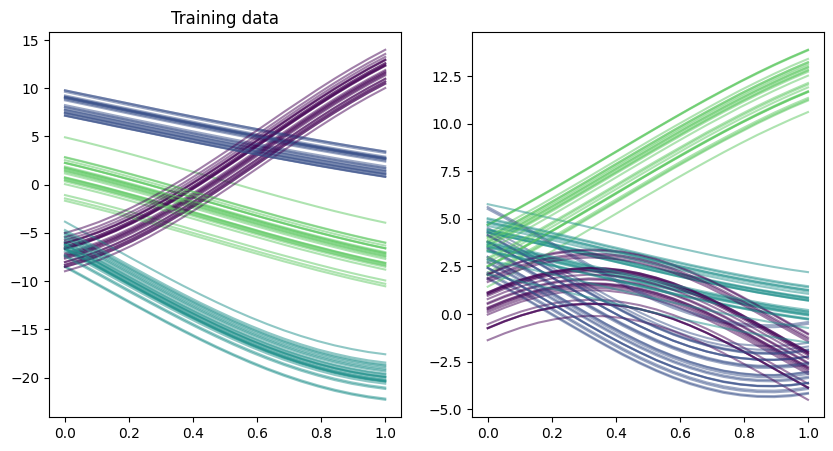

In [586]:
fig, axs = plt.subplots(1, F, figsize=(10, 5))
if F == 1: axs = [axs]
cmap = mpl.colormaps.get_cmap('viridis')
for j in range(F):
    for i in range(len(Xs)):
        axs[j].plot(ts, Xs[i, :, j].detach().numpy().T, alpha=0.5, color=cmap(targets[i]/c))

legend_elements = [Line2D([0], [0], color=cmap(i/len(Xs)), lw=2, label=f'Group {i}') 
                   for i in range(len(Xs))]
#axs[0].legend(handles=legend_elements)
axs[0].set_title("Training data")
plt.show()

In [587]:
def apply_pca(X_input, r):
    # 1. Input Validation and Reshaping
    # We treat (T, F) as a single "feature vector" of size D
    N = X_input.shape[0]
    original_shape = X_input.shape
    
    # Flatten all dimensions except the batch dimension (N)
    # Shape becomes (N, D), where D = T * F
    X_flat = X_input.view(N, -1)
    
    # 2. Centering
    #mean_vec = X_flat.mean(dim=0)
    X_centered = X_flat #X_centered = X_flat - mean_vec

    # 3. Covariance Matrix
    # torch.cov expects rows as variables, so we transpose to (D, N)
    # Result C is (D, D)
    C = torch.cov(X_centered.T) 
    
    # 4. Eigen-decomposition
    # eigh is faster/stable for symmetric matrices (like covariance)
    m_eigvals, m_eigvecs = torch.linalg.eigh(C)

    # 5. Sort Descending
    # eigh returns eigenvalues in ascending order, so we flip
    idx = torch.argsort(m_eigvals, descending=True)
    m_eigvals = m_eigvals[idx]
    m_eigvecs = m_eigvecs[:, idx]

    # 6. Projection (Scores)
    # Select top r eigenvectors
    top_vecs = m_eigvecs[:, :r]
    
    # Project data onto the principal components
    # (N, D) @ (D, r) -> (N, r)
    scores = X_centered @ top_vecs

    # 7. Reconstruction
    # Map back to high-dimensional space
    # (N, r) @ (r, D) -> (N, D)
    X_recon_flat = (scores @ top_vecs.T) #+ mean_vec
    
    # 8. Unflatten to original shape (N, T, F)
    X_recon = X_recon_flat.view(original_shape)

    return X_recon, m_eigvals[:r], m_eigvecs[:, :r].view(F, T, r)

In [588]:
X_recon, m_eigvals, m_eigvecs = apply_pca(Xs, r)

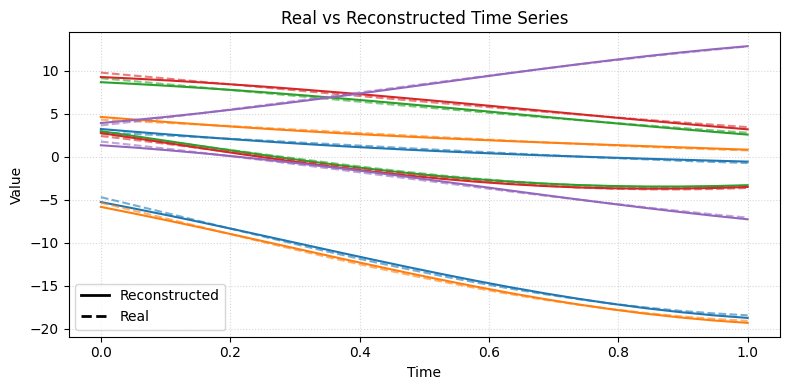

In [589]:
cmap = mpl.colormaps['tab10']

plt.figure(figsize=(8, 4))
rand_ind = np.random.choice(Xs.shape[0], size=5, replace=False)
for i, idx in enumerate(rand_ind):
    color = cmap(i)
    plt.plot(ts, X_recon[idx], color=color)
    plt.plot(ts, Xs[idx], '--', color=color, alpha=0.6)

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Real vs Reconstructed Time Series')
legend_elements = [
    Line2D([0], [0], color='k', lw=2, label='Reconstructed'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='Real')
]
plt.legend(handles=legend_elements, loc='best')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [590]:
def get_J(X, m, evals, evecs, alpha):
    """
    X: [B, T, F]
    m: [K, T, F]
    evals: [K, R]
    evecs: [K, T, R]
    """
    # 1. Determinant Term (Pre-factor)
    # Assuming shared temporal covariance across features: (det)^(-F/2)
    # 1D formula: 1/sqrt(prod(1 - 2*alpha*lambda))
    # F-D formula: (1/sqrt(prod(1 - 2*alpha*lambda)))^F
    log_det = -0.5 * F * torch.sum(torch.log(1 - 2 * alpha * evals), dim=-1)
    p1 = torch.exp(log_det) # [K]

    # 2. Exponent Term
    # (X - m) projection onto eigenvectors
    # a1: [B, K, T, F]
    a1 = X[:, None, :, :] - m[None, :, :, :] 
    
    # Project onto basis: sum over T
    # [B, K, T, F] * [K, T, R] -> [B, K, F, R]
    proj = torch.einsum('bktf,ktr->bkfr', a1, evecs) * dt 
    
    # Square and normalize by eigenvalues
    # sum over Features F
    # [B, K, F, R] -> [B, K, R]
    proj_sq_sum_f = torch.sum(torch.square(proj), dim=2)
    
    # Divide by (1 - 2*alpha*lambda)
    c1 = proj_sq_sum_f / (1 - 2 * alpha * evals[None, :]) # [B, K, R]
    
    # Sum over R and apply alpha
    exponent = alpha * torch.sum(c1, dim=-1) # [B, K]
    
    d1 = p1 * torch.exp(exponent)
    return torch.mean(d1, dim=0) # Mean over batch -> [K]


def get_I(X, m, evals, evecs, alpha):
    """
    Inputs same as get_J.
    Calculates interaction between component means.
    """
    # 1. Determinant Term
    # Evals sum: lambda_k + lambda_s. Shape: [K, K, R]
    evals_sum = evals[:, None, :] + evals[None, :, :]
    
    log_det = -0.5 * F * torch.sum(torch.log(1 - 2 * alpha * evals_sum), dim=-1)
    p2 = torch.exp(log_det) # [K, K]

    # 2. Exponent Term
    # Difference of means: [K, K, T, F]
    a2 = m[:, None, :, :] - m[None, :, :, :]
    
    # Average of eigenvectors: [K, K, T, R]
    b2 = (evecs[:, None, :, :] + evecs[None, :, :, :]) / 2
    
    # Project: sum over T -> [K, K, F, R]
    proj = torch.einsum('ijtf,ijtr->ijfr', a2, b2) * dt
    
    # Square and sum over F -> [K, K, R]
    proj_sq_sum_f = torch.sum(torch.square(proj), dim=2)
    
    # Divide by eigenvalue sums
    d2 = proj_sq_sum_f / (1 - 2 * alpha * evals_sum)
    
    exponent = alpha * torch.sum(d2, dim=-1)
    
    return p2 * torch.exp(exponent) # [K, K]

def MMD_Loss(I, J, pi):
    # Standard quadratic form for MMD
    # Note: We omit the X-X term (E1) for optimization as it is constant w.r.t parameters
    E2 = torch.dot(pi, J)
    E3 = pi @ I @ pi
    return (E3 - 2*E2) 

In [591]:
kernels = [lambda x1, x2, s=s: rbf_kernel(x1, x2, sigma=s) for s in sigmas]
K_mat = torch.stack([kernel(t1, t2) for kernel in kernels]) * dt # [2 x 100 x 100]

evals, evecs = torch.linalg.eigh(K_mat)
# eigh returns eigenvalues in ascending order, so take the last R
evals, evecs = evals[..., -R:], evecs[..., -R:]
evals, evecs = torch.flip(evals, dims=[-1]), torch.flip(evecs, dims=[-1])

## 1.1 Train using gradient descent

In [606]:
m_scores = nn.Parameter(torch.randn(K, r) * 2.)
pi_logits = nn.Parameter(torch.ones((K,)))

m = (m_scores @ m_eigvecs.transpose(2,1)).permute(1,2,0)  # [K, T]
J = get_J(Xs, m, evals, evecs, alpha)
I = get_I(Xs, m, evals, evecs, alpha)
loss_reg = m_scores.square().mean() * 1e-8
loss = MMD_Loss(I, J, pi_logits)
MMD_Loss(I, J, pi_logits)

tensor(7.8161, grad_fn=<SubBackward0>)

In [607]:
J = get_J(Xs, real_means, evals, evecs, alpha)
I = get_I(Xs, real_means, evals, evecs, alpha)
loss_reg = m_scores.square().mean() * 1e-8
true_pi_logits = torch.tensor(samples_per_cluster/np.sum(samples_per_cluster)).float()
loss = MMD_Loss(I, J, true_pi_logits)
print(MMD_Loss(I, J, true_pi_logits))

tensor(-0.8334)


In [608]:
optimizer = torch.optim.RMSprop([m_scores], lr=0.1)
pbar = tqdm(range(1000))
for i in pbar:
    optimizer.zero_grad()
    
    m = (m_scores @ m_eigvecs.transpose(2,1)).permute(1,2,0)  # [K, T]
    J = get_J(Xs, m, evals, evecs, alpha)
    I = get_I(Xs, m, evals, evecs, alpha)
    pi = torch.softmax(pi_logits, dim=0)

    loss_reg = m_scores.abs().mean(0).mean() * lambd_reg #torch.sum(m.square(), axis=0).sum()*dt
    loss = MMD_Loss(I, J, pi) + loss_reg
    
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Total loss: {loss.item():.6f}, loss_reg: {loss_reg.item():.4f}")

Total loss: -0.813241, loss_reg: 0.0028:   1%|          | 10/1000 [00:00<00:09, 99.20it/s]

Total loss: -0.815456, loss_reg: 0.0042: 100%|██████████| 1000/1000 [00:10<00:00, 96.17it/s]


In [609]:
cost_matrix = torch.zeros((K, K))
for i in range(K):
    for j in range(K):
        cost_matrix[i, j] = torch.mean((real_means[i] - m[j])**2).item()

row_ind, col_ind = linear_sum_assignment(cost_matrix.numpy())
for true_idx, learned_idx in zip(row_ind, col_ind):
    mse = cost_matrix[true_idx, learned_idx].item()

In [610]:
estimated_pi = torch.softmax(pi, dim=0).detach().numpy()
print("Estimated pi: ", estimated_pi[col_ind])
print("True pi: ", K/np.sum(K))

Estimated pi:  [0.25 0.25 0.25 0.25]
True pi:  1.0


In [611]:
m_scores

Parameter containing:
tensor([[-6.5275e+00, -3.0664e-02, -1.0409e-01,  7.5736e-02],
        [-2.6091e-01,  1.5266e-01, -2.3401e-02,  4.0160e-02],
        [-1.0820e-01, -1.2048e-02, -4.7722e-02,  5.0467e-02],
        [-1.7081e-01,  2.5993e-02, -3.3571e+01,  2.5680e+01]],
       requires_grad=True)

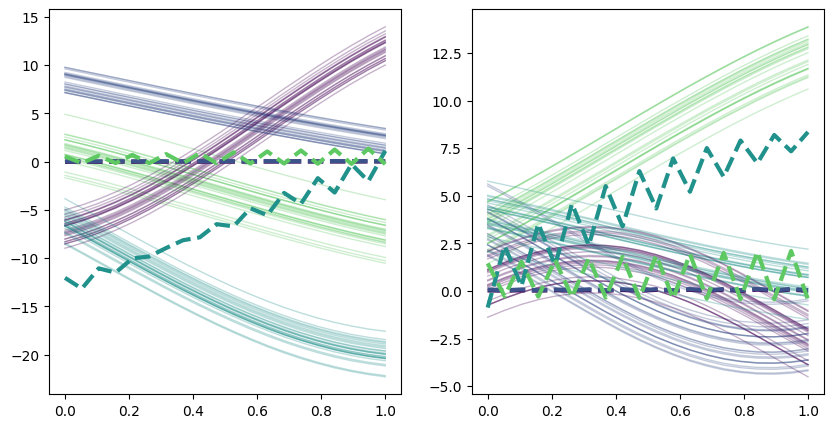

In [612]:
fig, axs = plt.subplots(1, F, figsize=(10, 5))
if F == 1: axs = [axs]
cmap = mpl.colormaps.get_cmap('viridis')

# Plot training data
for j in range(F):
    for i in range(len(Xs)):
        axs[j].plot(ts, Xs[i, :, j].detach().numpy().T, alpha=0.3, color=cmap(targets[i]/c), linewidth=1)

# Plot predicted means
for j in range(F):
    for i in range(K):
        axs[j].plot(ts, m[col_ind[i], :, j].detach().numpy(), color=cmap(i/K), lw=3, label=f'Predicted {i}', linestyle='--')

#ax.legend()
#ax.set_title("Training data and Predicted means")
plt.show()

In [599]:
# 3. Compara pi
reordered_pi = estimated_pi[col_ind]
true_pi = num/np.sum(num)

print(f"Estimated pi (reordered): {reordered_pi}")
print(f"True pi:                  {true_pi}")
print(f"Aboslute Error:           {np.abs(reordered_pi - true_pi)}")
print(f"Mean Absolute Error:           {np.mean(np.abs(reordered_pi - true_pi)):.6f}")

# 4. Visualiza
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i in range(K):
    axes[i].plot(ts, means[i].numpy(), 'k-', lw=3, label='True', alpha=0.7)
    learned_idx = col_ind[i]
    axes[i].plot(ts, m[learned_idx].detach().numpy(), 'r--', lw=2, label='Learned')
    axes[i].set_title(f'Grupo {i} (pi_true={true_pi[i]:.3f}, pi_est={reordered_pi[i]:.3f})')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim((-10,10))

plt.tight_layout()
plt.show()

NameError: name 'num' is not defined

## 1.2 Train $\pi$ using closed formula

In [ ]:
m_scores = nn.Parameter(torch.randn((K,r)))
pi = torch.full((K,), 1/K)

In [ ]:
optimizer = torch.optim.Adam([m_scores], lr=lr)
pbar = tqdm(range(1000))
for i in pbar:
    optimizer.zero_grad()
    
    m = m_scores @ m_eigvecs[:, :r].T  # [K, T]
    J = get_J(X, m, evals, evecs, alpha)
    I = get_I(X, m, evals, evecs, alpha)
    E1, E2, E3 = MMD(X, I, J, pi)
    loss_reg = m_scores.square().mean(0).mean()#torch.sum(m.square(), axis=0).sum()*dt

    loss = (E1 - 2*E2 + E3) + loss_reg*lambd_reg
    loss.backward()
    optimizer.step()

    if i%10==0:
        with torch.no_grad():
            I_inv = torch.inverse(I)
            Ones = torch.ones_like(pi)
            pi = I_inv @ J - ((torch.dot(Ones, I_inv @ J) - 1)/torch.dot(Ones, I_inv @ Ones)) * (I_inv @ Ones)
            pi = torch.clamp(pi, min=0, max=1)
            pi /= 1e-7+torch.sum(pi)
    pbar.set_description(f"Total loss: {loss.item():.4f}, E1: {E1.item():.4f}, E2: {E2.item():.4f}, E3: {E3.item():.4f}, loss_reg: {loss_reg.item():.4f}")

Total loss: 0.0181, E1: 0.5535, E2: 0.5414, E3: 0.5474, loss_reg: 164.2652: 100%|██████████| 1000/1000 [00:10<00:00, 99.41it/s]


In [ ]:
cost_matrix = torch.zeros((K, K))
for i in range(K):
    for j in range(K):
        cost_matrix[i, j] = torch.mean((means[i] - m[j])**2).item()

row_ind, col_ind = linear_sum_assignment(cost_matrix.numpy())
for true_idx, learned_idx in zip(row_ind, col_ind):
    mse = cost_matrix[true_idx, learned_idx].item()

In [ ]:
estimated_pi = torch.softmax(pi, dim=0).detach().numpy()
print("Estimated pi: ", estimated_pi[col_ind])
print("True pi: ", num/np.sum(num))

Estimated pi:  [0.25214413 0.28523284 0.23047742 0.23214562]
True pi:  [0.20833333 0.41666667 0.16666667 0.20833333]


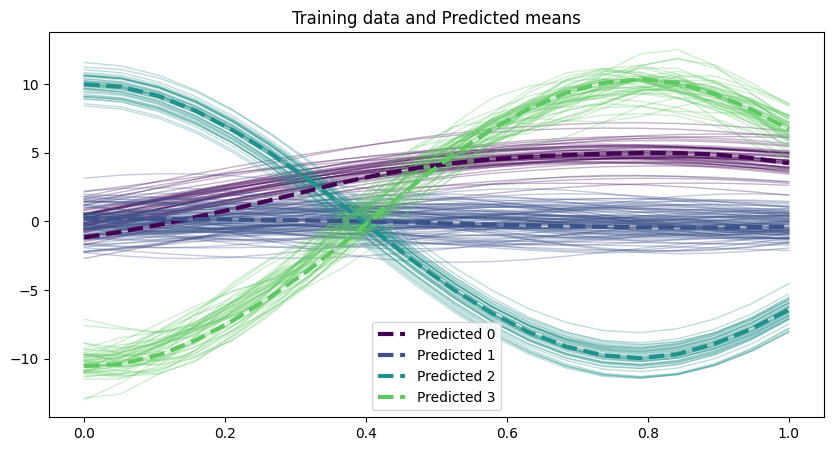

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
cmap = mpl.colormaps.get_cmap('viridis')

# Plot training data
for i in range(len(Xs)):
    ax.plot(ts, Xs[i].detach().numpy().T, alpha=0.3, color=cmap(i/len(Xs)), linewidth=1)

# Plot predicted means
for i in range(K):
    ax.plot(ts, m[col_ind[i]].detach().numpy(), color=cmap(i/K), lw=3, label=f'Predicted {i}', linestyle='--')

ax.legend()
ax.set_title("Training data and Predicted means")
plt.show()

In [ ]:
estimated_pi = pi.detach().numpy()
print("Estimated pi: ", estimated_pi[col_ind])
print("True pi: ", num/np.sum(num))

Estimated pi:  [0.26229474 0.38559967 0.17244679 0.1796587 ]
True pi:  [0.20833333 0.41666667 0.16666667 0.20833333]


## Test against Empirical MMD

In [ ]:
num_samples = 300
Y = [MultivariateNormal(m[i].detach(), rbf_kernel(t1, t2, sigma=sigmas[i]) + 1e-5*torch.eye(T)).sample((1,)) for i in np.random.choice(4, size=num_samples, p=pi.detach().numpy())]
y = torch.concatenate(Y, dim=0)

In [ ]:
e1 = torch.mean(rbf_fkernel(X[None, :, :], X[:, None, :], dt, alpha=alpha))
e2 = rbf_fkernel(y[None, :, :], X[:, None, :], dt, alpha=alpha).mean(0).mean(0)
e3 = torch.mean(rbf_fkernel(y[None, :, :], y[:, None, :], dt, alpha=alpha))

loss = e1 - 2*e2 + e3

In [ ]:
J = get_J(X, m, evals, evecs, alpha)
I = get_I(X, m, evals, evecs, alpha)
E1, E2, E3 = MMD(X, I, J, pi)

Loss = E1 - 2*E2 + E3

In [ ]:
print(f"Empirical Total loss:\t\t {loss.item():2.4f}\tE1: {e1.item():7.4f}, E2: {e2.item():7.4f}, E3: {e3.item():7.4f}")
print(f"Approximation Total loss:\t {Loss.item():2.4f}\tE1: {E1.item():7.4f}, E2: {E2.item():7.4f}, E3: {E3.item():7.4f}")

Empirical Total loss:		 0.0019	E1:  0.5535, E2:  0.5603, E3:  0.5690
Approximation Total loss:	 0.0181	E1:  0.5535, E2:  0.5414, E3:  0.5474


## Test that Empirical MMD is the same as Calculated

In [ ]:
pi = torch.tensor(num/num.sum()).type(torch.float32)
means = torch.tensor(np.array(means, dtype=np.float32))

num_samples = 800
Y = [MultivariateNormal(means[i].detach(), rbf_kernel(t1, t2, sigma=sigmas[i]) + 1e-5*torch.eye(T)).sample((1,)) for i in np.random.choice(len(pi), size=num_samples, p=pi.detach().numpy())]
y = torch.concatenate(Y, dim=0)

In [ ]:
e1 = torch.mean(rbf_fkernel(X[None, :, :], X[:, None, :], dt, alpha=alpha))
e2 = rbf_fkernel(y[None, :, :], X[:, None, :], dt, alpha=alpha).mean(0).mean(0)
e3 = torch.mean(rbf_fkernel(y[None, :, :], y[:, None, :], dt, alpha=alpha))

loss = e1 - 2*e2 + e3

In [ ]:
J = get_J(X, means, evals, evecs, alpha)
I = get_I(X, means, evals, evecs, alpha)
E1, E2, E3 = MMD(X, I, J, pi)

Loss = E1 - 2*E2 + E3

In [ ]:
print(f"Empirical Total loss:\t\t {loss.item():2.4f}\tE1: {e1.item():7.4f}, E2: {e2.item():7.4f}, E3: {e3.item():7.4f}")
print(f"Approximation Total loss:\t {Loss.item():2.4f}\tE1: {E1.item():7.4f}, E2: {E2.item():7.4f}, E3: {E3.item():7.4f}")

Empirical Total loss:		 0.0002	E1:  0.5535, E2:  0.5497, E3:  0.5462
Approximation Total loss:	 0.0166	E1:  0.5535, E2:  0.5405, E3:  0.5440
